Author: @Bahae-Eddine Madir

# Finite Differences Method for Stefan's Problem

In [1]:
import sys
import os
sys.path.insert(1, './Utilities/')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import use_solver, spsolve

In [3]:
from stefan import Stefan1D

In [4]:
delta = 0.05
x0, xn = 0., 1.
t0, tn = 5e-2, 1.

In [5]:
problem = Stefan1D(
    Th=1, 
    Tc=-0.5, 
    Tf=0, 
    L=.2, 
    alpha=0.01, 
    c=0.001, 
    xref=1, 
    tref=1
)

Ste = problem.Ste
Fo = problem.Fo
Th, Tc, T = problem.Th, problem.Tc, problem.T
print('Ste: %.3f, Fo: %.3f, Th: %.3f, Tc: %.3f' % (Ste, Fo, Th, Tc))

Ste: 0.005, Fo: 0.010, Th: 1.000, Tc: -0.500


In [6]:
case = '1D_'+str(Ste)
savedir = './ref_' + case + '/'
os.makedirs(savedir, exist_ok=True)
save = True

In [7]:
def r(T):
    N = Fo
    D = 1. + (1./Ste)* (1./(2* delta))* (1. - np.tanh(T/delta)**2)
    return N/D

def dr(T):
    N = Fo* np.tanh(T/delta)* (1. - np.tanh(T/delta)**2)
    D = Ste* (delta**2)* (1. + (1./Ste)* (1./(2* delta))* (1. - np.tanh(T/delta)**2))**2
    return N/D

In [8]:
def lap_matrix(n, a=-2):
    """Laplacian matrix"""
    
    ones = np.ones(n - 2)
    d = np.hstack([a, -2* ones, a])
    ds = np.hstack([0, ones])
    di = np.hstack([ones, 0])

    return diags([di, d, ds], [-1, 0, 1])

In [9]:
def jacobien(theta, k, A):
    
    d  = 1. - k * dr(theta) * (A @ theta) + 2* k * r(theta)
    d[0], d[-1] = 1., 1.
    
    ds = - k * r(theta[:-1])
    ds[0] = 0.
    
    di = - k * r(theta[1:])
    di[-1] = 0.
    
    return diags([di, d, ds], [-1, 0, 1]).tocsr()

In [10]:
def newton(u0, k, max_iter=1000, tolerance=1e-9):

    f = lambda x, k, A: x - k* r(x)* (A @ x)
    g = lambda x, k, A: x + k* r(x)* (A @ x)
    
    v = u0
    for _ in range(max_iter):

        A = lap_matrix(u0.shape[0], a=0.)
        jac = jacobien(v, k, A)
        F = f(v, k, A) - g(u0, k, A)
        
        use_solver(useUmfpack=False)
        d = spsolve(jac, F)

        # Newton update
        v = v - d
        norm = np.linalg.norm(d, ord=np.inf)
        
        if norm < tolerance:
            return v
        
    print(f"Newton iterations didn't converge, norm: {norm:.3e}")

In [11]:
def save_sol(ti, x, u, log, save_x):
    x = x.reshape(-1, 1)[::save_x]
    u = u.reshape(-1, 1)[::save_x]
    solution = (
        ti* np.ones_like(x), 
        x,
        u
    )
    solution = np.hstack(solution)
    log.append(solution)
    return log

In [12]:
def solve(nt, nx, save_t=1, save_x=1):
    
    t = np.linspace(t0, tn, nt)
    x = np.linspace(x0, xn, nx)
    dx = (xn - x0)/(nx - 1)
    dt = (tn - t0)/(nt - 1)
    k = dt/(2* dx**2)
    
    u0 = T(t[0], x)
    save = list()

    log = list()
    for i, ti in enumerate(t):
        u1 = newton(u0, k)

        # save solution
        if i % save_t == 0:
            log = save_sol(ti, x, u0, log, save_x)
        
        # time update
        u0 = u1

    log = save_sol(ti, x, u0, log, save_x)
    log = np.vstack(log)
    return log

In [13]:
%%time
nt = 1001
nx = 1001
solution = solve(nt, nx, save_t=10, save_x=4)

CPU times: user 1.74 s, sys: 261 ms, total: 2 s
Wall time: 2 s


In [14]:
x = np.linspace(x0, xn, nx)
t = np.linspace(t0, tn, nt)
print(x[::10].shape)
print(t[::10].shape)

(101,)
(101,)


In [15]:
# Save
header = "Ste=%f, Fo=%f, delta=%f\nt, x, T"%(Ste, Fo, delta)
np.savetxt(
    savedir+'ref_1D', 
    solution,
    delimiter = ',\t',
    header=header
)

# Convergence curve

In [16]:
%%time

U = []
h = []

j = 1

for _ in range(9) :
    
    n = j* 100 + 1
    print(1/n)
    sol = solve(n, n)
    
    _, _, u = np.hsplit(sol, 3)
    
    u = u.reshape(-1, n)
    
    l = range(0, n, j)
    
    U.append(u[l, l])
    h.append(1/n)
    
    j = 2* j

0.009900990099009901
0.004975124378109453
0.0024937655860349127
0.0012484394506866417
0.0006246096189881324
0.00031240237425804435
0.0001562255897516013
7.81188969611749e-05
3.906097418069607e-05
CPU times: user 8min 32s, sys: 4min 24s, total: 12min 56s
Wall time: 13min 39s


In [17]:
def ERRL2(U, Uex) :
    return np.linalg.norm(U - Uex, 2) / np.linalg.norm(Uex, 2)

In [18]:
err = []

for i, u in enumerate(U[:-1]) :
    e = ERRL2(u.flatten(), U[-1].flatten())
    err.append(e)
    print('errL2 : %.3e' %(e))

errL2 : 7.949e-03
errL2 : 5.467e-03
errL2 : 1.357e-03
errL2 : 2.122e-04
errL2 : 5.398e-05
errL2 : 1.512e-05
errL2 : 2.869e-06
errL2 : 9.004e-07


In [19]:
h = h[:-1]

In [20]:
h

[0.009900990099009901,
 0.004975124378109453,
 0.0024937655860349127,
 0.0012484394506866417,
 0.0006246096189881324,
 0.00031240237425804435,
 0.0001562255897516013,
 7.81188969611749e-05]

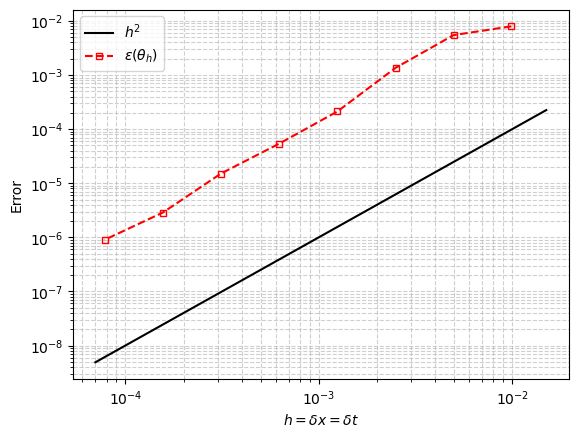

In [21]:
fig, ax = plt.subplots(1, 1)

plt.xscale('log')
plt.yscale('log')

ax.grid(True, which='both', alpha = .6, ls='dashed')

plt.plot(np.array([0.015, 0.00007]), np.array([0.015, 0.00007])**2, 'k', alpha=1, label = '$h^2$')
plt.plot(h, err, 'r--s', markersize=4, markerfacecolor="none", label = r'$\epsilon(\theta_h)$')

ax.set_xlabel('$h = \delta x = \delta t$', fontsize = 10)
ax.set_ylabel('Error', fontsize = 10)

plt.legend()
plt.savefig(savedir+'FD.pdf', bbox_inches ='tight')
plt.savefig(savedir+'FD.png', bbox_inches ='tight')
plt.show()